In [1]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
import pandas as pd
import datetime
from IQAEBinom_OnlyFinalRound import IQAEBinom_OnlyFinalRound

In [2]:
pTrue = 0.2
nGrover = 100
nShot = 100

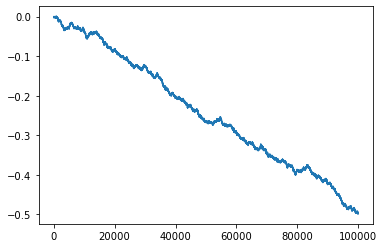

In [ ]:
nEstim = 100000
estims = np.array([])
p1ObsFinals = np.array([])
for _ in range(nEstim):
    estim, p1ObsFinal = IQAEBinom_OnlyFinalRound(pTrue, nGrover, nShot)
    estims = np.append(estims, estim)
    p1ObsFinals = np.append(p1ObsFinals, p1ObsFinal)

errors = estims - pTrue
ax = plt.gca()
plt.plot(errors.cumsum())
plt.show()

In [ ]:
# bias見積り
np.mean(errors)

-4.963638683682018e-06

In [ ]:
# bias見積りの統計誤差
np.sqrt(np.var(errors) / nEstim)

6.340263513209247e-07

In [4]:
from BiasCorrection import BiasCordeiroKlein, BiasTaylorExpTo2nd, BiasTaylorExpTo3rd, BiasTaylorExpTo4th, BiasExact

In [ ]:
# Cordeiro-Kleinのbias理論式　→　合わず...
BiasCordeiroKlein(pTrue, nGrover, nShot)

-2.384697028700929e-05

テイラー近似によるバイアス理論式は2シグマ以内で合ってる

In [ ]:
BiasTaylorExpTo2nd(pTrue, nGrover, nShot)

-5.90605088095259e-06

In [ ]:
BiasTaylorExpTo3rd(pTrue, nGrover, nShot)

-5.826542542985285e-06

In [5]:
nEstim = 1000000
nShot = 50
nGrovers = np.arange(100, 500, 1)
avgErrors = np.array([])
errStDevs = np.array([])
biasTaylor = np.array([])
for nG in nGrovers:
    errs = IQAEBinom_OnlyFinalRound(pTrue, nG, nShot, nEstim=nEstim) - pTrue
    avgErrors = np.append(avgErrors, np.mean(errs))
    errStDevs = np.append(errStDevs, np.std(errs) / np.sqrt(nEstim))
    biasTaylor = np.append(biasTaylor, BiasTaylorExpTo4th(pTrue, nG, nShot))

In [6]:
pd.options.display.float_format = '{:.4e}'.format
pd.set_option('display.max_rows', 100)
dfErrorBias = pd.DataFrame({"nGrover": nGrovers, "avgError": avgErrors, "errorStd": errStDevs, "bias": biasTaylor})
dfErrorBias["(avgErr-bias)/errorStd"] = (dfErrorBias["avgError"] - dfErrorBias["bias"]) / dfErrorBias["errorStd"]
dfErrorBias["p1Final"] = np.sin((2 * dfErrorBias["nGrover"] + 1) * np.arcsin(np.sqrt(pTrue))) ** 2
print(dfErrorBias)

     nGrover    avgError   errorStd        bias  (avgErr-bias)/errorStd  \
0        100 -1.2705e-05 2.8650e-07 -1.2331e-05             -1.3031e+00   
1        101  1.3531e-04 3.4558e-07  1.5053e-04             -4.4021e+01   
2        102  1.2862e-06 2.7874e-07  6.5972e-07              2.2477e+00   
3        103 -1.0973e-04 3.5137e-07 -9.2431e-05             -4.9234e+01   
4        104  1.3822e-05 2.7571e-07  1.3694e-05              4.6202e-01   
..       ...         ...        ...         ...                     ...   
395      495  1.5111e-07 5.7697e-08  1.4346e-07              1.3243e-01   
396      496 -2.2606e-05 7.3273e-08 -1.8732e-05             -5.2870e+01   
397      497  2.9152e-06 5.7980e-08  2.8937e-06              3.6995e-01   
398      498 -3.5554e-06 5.8127e-08 -3.4615e-06             -1.6155e+00   
399      499  1.5784e-05 7.0704e-08  1.2129e-05              5.1698e+01   

       p1Final  
0   7.5639e-01  
1   1.6122e-02  
2   5.1458e-01  
3   9.7571e-01  
4   2.1902e-01

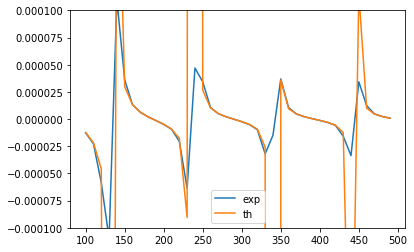

In [7]:
ax = plt.gca()
plt.plot(nGrovers[0::10], avgErrors[0::10], label="exp")
plt.plot(nGrovers[0::10], biasTaylor[0::10], label="th")
ax.set_ylim(-1e-4, 1e-4)
ax.legend()
plt.show()

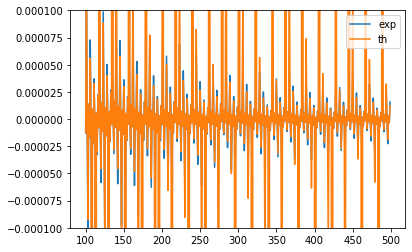

In [8]:
ax = plt.gca()
plt.plot(nGrovers, avgErrors, label="exp")
plt.plot(nGrovers, biasTaylor, label="th")
ax.set_ylim(-1e-4, 1e-4)
ax.legend()
plt.show()

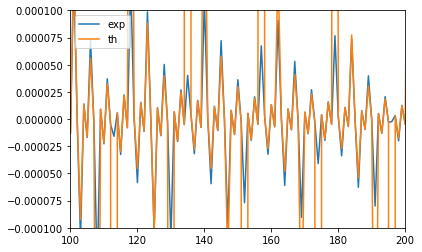

In [9]:
ax = plt.gca()
plt.plot(nGrovers, avgErrors, label="exp")
plt.plot(nGrovers, biasTaylor, label="th")
ax.set_xlim(100, 200)
ax.set_ylim(-1e-4, 1e-4)
ax.legend()
plt.show()

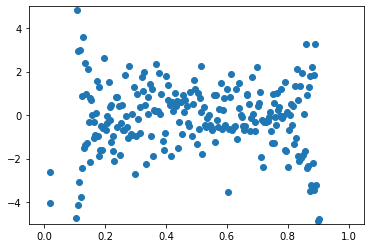

In [10]:
ax = plt.gca()
ax.set_ylim(-5,5)
plt.scatter(dfErrorBias["p1Final"], dfErrorBias["(avgErr-bias)/errorStd"])

In [11]:
dfErrorBias["biasExact"] = [BiasExact(pTrue, nG, nShot) for nG in nGrovers]

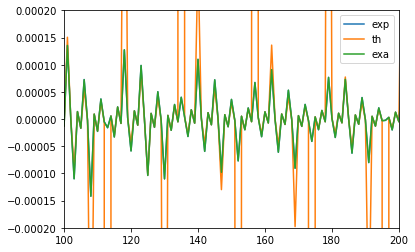

In [15]:
ax = plt.gca()
plt.plot(nGrovers, avgErrors, label="exp")
plt.plot(nGrovers, biasTaylor, label="th")
plt.plot(nGrovers, dfErrorBias["biasExact"], label="exa")
ax.set_xlim(100, 200)
ax.set_ylim(-2e-4, 2e-4)
ax.legend()
plt.show()